#### Inspecting the dataset

We start by importing the libraries and the dataset

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

Following that, the shape, information and dataset will be shown.

In [236]:
print("Dataset shape:", df.shape)  
display(df.head())  

print("\nInfo:\n")
df.info()  

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


#### Stroke distribution

In [237]:
df['stroke'].value_counts()
df['stroke'].value_counts(normalize=True)

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

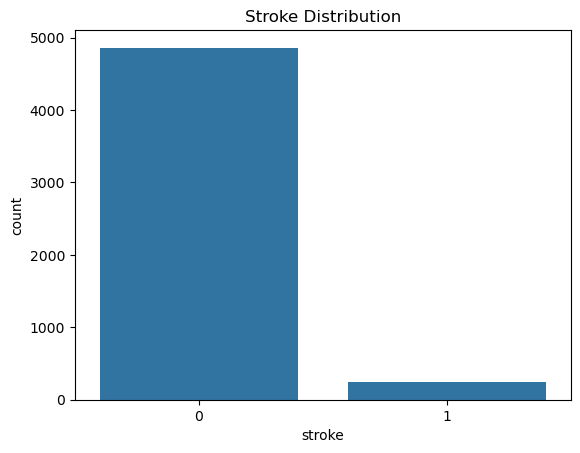

In [238]:
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

The dataset is highly imbalanced: only 5% of people had a stroke. This will guide modeling decisions, such as using class weights or evaluation metrics beyond accuracy.

stroke
0    41.971545
1    67.728193
Name: age, dtype: float64

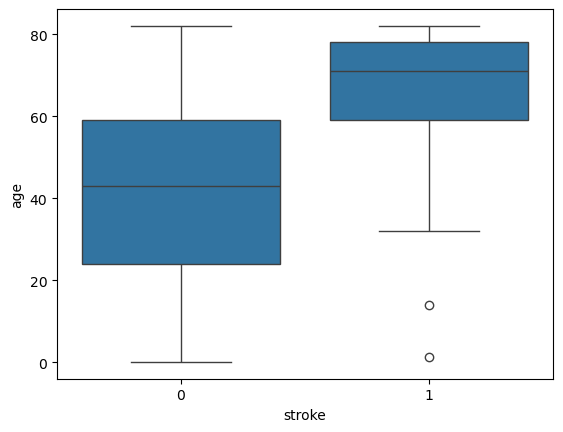

In [239]:
sns.boxplot(x='stroke', y='age', data=df)
df.groupby('stroke')['age'].mean()

<Axes: xlabel='stroke', ylabel='avg_glucose_level'>

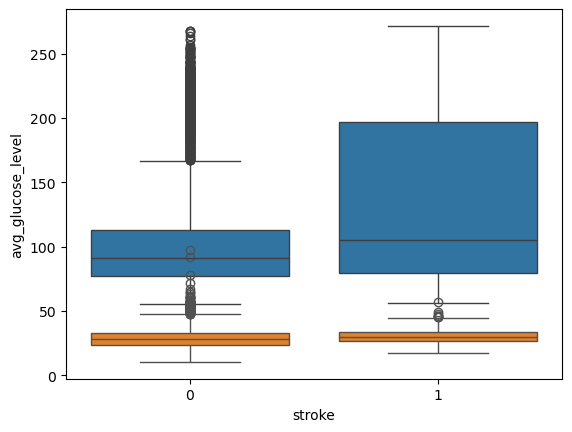

In [240]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
sns.boxplot(x='stroke', y='bmi', data=df)

People who had a stroke tend to have higher average glucose levels and slightly higher BMI.

#### Missing values

Let's now check for missing values.

In [241]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

As we saw, there are 201 missing values in the ``bmi`` column, so let's fill them using the median.

In [242]:
df.fillna({'bmi': df['bmi'].median()}, inplace=True)
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

There are no missing values now.

#### Categorical values

Now we inspect the unique values for each categorical feature in order to help us get a better view at them.

In [243]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())

gender ['Male' 'Female' 'Other']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


There's at least 1 person with smoking status as 'Unknown'. The rest seems correct, although there is an extra gender that does not exist whatsoever: let's see that.

In [244]:
num_other_gender_rows = df[df['gender'] == 'Other'].shape[0]
print('Total other gender rows:', num_other_gender_rows)

Total other gender rows: 1


It's really just one person, so let's just discover the index in order to remove that row.

In [245]:
df[df['gender'] == 'Other']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [246]:
df.drop(3116, inplace = True)
print('Genders:', df['gender'].unique())

Genders: ['Male' 'Female']


Next, we check how many people have an unknown smoking status.

In [247]:
num_unk_smoke = df[df['smoking_status'] == 'Unknown'].shape[0]
print('Total number of people with unknown people smoking status:', num_unk_smoke)

Total number of people with unknown people smoking status: 1544


1544 people have an unknown smoking status, that is 30% of the whole dataset. We'll need to find an effective way to determine these statuses.

#### Numerical values